# Loss Landscape Visualization

Sweeps all pairs of trainable AdEx parameters over a grid, simulates at each point,
and plots the loss surfaces as:
1. A lower-triangle grid of 2D contour plots (21 pairs)
2. Individual 3D surface plots with contour projection (Ackley-style)

In [1]:
import copy
import logging
import time
from itertools import combinations

import jax
import jax.numpy as jnp
import numpy as np
from jax import config
from jax.scipy.special import logsumexp

from ADoptEX.core import simulate_jaxley
from ADoptEX.core.data import TraceData
from ADoptEX.core.parameters import DEFAULT_PARAMS, NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.loss import inject_spike_peaks

from ADoptEX.plotting import (
    trace_stim_window_plot,
)

from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

import matplotlib.pyplot as plt
from matplotlib import cm


## 1. Load & Crop Data

In [2]:
initial_params = dict(NAUD_PARAMETERS["adaptation"])
initial_params["v_threshold"] = 0.0
print(initial_params)

current_pA = initial_params["I"]

t_max_ms = 100
dt_ms = 0.025
T = np.linspace(0, t_max_ms, int(t_max_ms / dt_ms))

sim_init = simulate_jaxley(
    params=initial_params,
    stim_current_pA=current_pA,
    stim_duration_ms=100,
    dt_ms=dt_ms,
    t_max_ms=t_max_ms,
    stim_delay_ms=0.0,
    use_surrogate=False,
)

SPIKE_PEAK_MV = 35.0
for st in sim_init.spike_times:
    idx = int(st / dt_ms)
    if 0 <= idx < len(sim_init.voltage):
        sim_init.voltage[idx] = SPIKE_PEAK_MV

T = np.append(T, T[-1] + dt_ms)
print(len(T))

INFO:2026-04-22 15:08:34,937:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


{'C_m': 200.0, 'g_L': 12.0, 'E_L': -70.0, 'v_T': -50.0, 'delta_T': 2.0, 'v_reset': -58.0, 'v_threshold': 0.0, 'tau_w': 300.0, 'a': 2.0, 'b': 60.0, 'I': 500.0}


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:82: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
4001


# Loss function definition

In [3]:
# --- Deistler preprocessing ---
def sliding_window_max(v: jnp.ndarray, window_size: int, stride: int) -> jnp.ndarray:
    """Sliding-window max reduction via jax.lax.reduce_window (differentiable)."""
    return jax.lax.reduce_window(
        v,
        init_value=-jnp.inf,
        computation=jax.lax.max,
        window_dimensions=(window_size,),
        window_strides=(stride,),
        padding="VALID",
    )


def rescale_unit(v: jnp.ndarray, v_min: float, v_max: float, eps: float = 1e-8) -> jnp.ndarray:
    """Rescale to [0, 1] using pre-computed min/max (shared across sim and target)."""
    return (v - v_min) / (v_max - v_min + eps)


# --- Soft-DTW ---
_LARGE = 1e9  # stand-in for +inf; softmin treats -_LARGE/gamma as negligible


def _softmin(values: jnp.ndarray, gamma: float) -> jnp.ndarray:
    return -gamma * logsumexp(-values / gamma)


def soft_dtw_from_cost(C: jnp.ndarray, gamma: float = 1.0) -> jnp.ndarray:
    """Soft-DTW distance from a pre-built cost matrix C of shape (n, m).

    R[0, 0] = 0; R[0, j>0] = R[i>0, 0] = +inf (approximated by _LARGE).
    R[i, j] = C[i-1, j-1] + softmin_gamma(R[i-1, j-1], R[i-1, j], R[i, j-1]).
    Returns R[n, m].
    """
    n, m = C.shape

    def process_row(R_prev: jnp.ndarray, C_row: jnp.ndarray):
        # R_prev has shape (m+1,); C_row has shape (m,).
        def col_step(R_curr_prev, inputs):
            R_diag, R_up, C_val = inputs
            R_curr = C_val + _softmin(jnp.stack([R_diag, R_up, R_curr_prev]), gamma)
            return R_curr, R_curr

        col_inputs = (R_prev[:-1], R_prev[1:], C_row)
        _, R_curr_rest = jax.lax.scan(col_step, _LARGE, col_inputs)
        R_curr = jnp.concatenate([jnp.array([_LARGE]), R_curr_rest])
        return R_curr, None

    R_init = jnp.concatenate([jnp.zeros(1), jnp.full(m, _LARGE)])
    R_final, _ = jax.lax.scan(process_row, R_init, C)
    return R_final[-1]

# --- Soft-DTW loss factory (Deistler preprocessing + divergence form) ---
def make_soft_dtw_loss_fn(
    cell,
    data_stimuli,
    t_max: float,
    dt_ms: float,
    exp_voltage: jnp.ndarray,
    stim_end_index: int,
    *,
    window_size: int = 50,
    stride: int = 30,
    gamma: float = 0.5,
    lambda_temp: float = 10.0,
    spike_peak_mv: float | None = 35.0,
    use_divergence: bool = True,
):
    """Build a closure `params -> scalar loss` computing soft-DTW on the
    sliding-window-max-reduced, unit-rescaled voltage traces with an L1 +
    (normalized) temporal-penalty cost.

    Cost: C[i, j] = |x_i - y_j| + lambda_temp * |i - j| / (n - 1)
    Both terms live in [0, 1], so lambda_temp directly controls timing vs. amplitude.

    If `use_divergence=True` (default), returns the Cuturi & Blondel soft-DTW
    divergence D(x, y) = sdtw(x, y) - 0.5 * (sdtw(x, x) + sdtw(y, y)), which is
    non-negative and = 0 when x = y. This removes soft-DTW's intrinsic length-
    dependent bias (~gamma * log(3) per cell) that otherwise pushes the loss
    to large negative values, confusingly making a "better" fit look "worse".
    """
    import jaxley as jx

    exp_v = jnp.asarray(exp_voltage)

    # Precompute target preprocessing (static across training).
    exp_reduced = sliding_window_max(exp_v, window_size, stride)
    # Scale using the *reduced* target's min/max so the rescaled target covers [0, 1].
    v_min = float(jnp.min(exp_reduced))
    v_max = float(jnp.max(exp_reduced))
    exp_scaled = rescale_unit(exp_reduced, v_min, v_max)
    m = exp_scaled.shape[0]

    # Precompute sdtw(y, y) — constant baseline used by the divergence form.
    if use_divergence:
        j_idx_y = jnp.arange(m, dtype=exp_scaled.dtype)
        denom_y = jnp.maximum(jnp.asarray(m - 1, dtype=exp_scaled.dtype), 1.0)
        C_yy = jnp.abs(exp_scaled[:, None] - exp_scaled[None, :]) + lambda_temp * (
            jnp.abs(j_idx_y[:, None] - j_idx_y[None, :]) / denom_y
        )
        sdtw_yy = soft_dtw_from_cost(C_yy, gamma=gamma)
    else:
        sdtw_yy = jnp.asarray(0.0, dtype=exp_scaled.dtype)

    def loss_fn(params):
        results = jx.integrate(
            cell,
            params=params,
            data_stimuli=data_stimuli,
            delta_t=dt_ms,
            t_max=t_max,
        )
        voltage = results[0].flatten()
        min_len = min(len(voltage), len(exp_v))
        sim_v = voltage[:min_len]

        # Hard-inject peaks at spike timesteps (results[2] is 0/1 in the forward
        # pass from AdExSurrogate's Heaviside). Mirrors the manual injection on
        # the target trace so the sliding-window max sees the same peak height.
        if spike_peak_mv is not None:
            spikes = results[2].flatten()[:min_len]
            sim_v = inject_spike_peaks(sim_v, spikes, spike_peak_mv)

        sim_reduced = sliding_window_max(sim_v, window_size, stride)
        sim_scaled = rescale_unit(sim_reduced, v_min, v_max)
        n = sim_scaled.shape[0]

        denom = jnp.maximum(jnp.asarray(max(n, m) - 1, dtype=exp_scaled.dtype), 1.0)
        i_idx = jnp.arange(n, dtype=exp_scaled.dtype)[:, None]
        j_idx = jnp.arange(m, dtype=exp_scaled.dtype)[None, :]
        C_xy = jnp.abs(sim_scaled[:, None] - exp_scaled[None, :]) + lambda_temp * (
            jnp.abs(i_idx - j_idx) / denom
        )
        sdtw_xy = soft_dtw_from_cost(C_xy, gamma=gamma)

        if not use_divergence:
            return sdtw_xy

        # sdtw(x, x): full cost (amplitude + temporal), same form as C_yy.
        # Using only the temporal penalty here would make sdtw(x, x) != sdtw(y, y)
        # even when x == y, breaking the divergence identity D(x, x) = 0.
        i_only = jnp.arange(n, dtype=exp_scaled.dtype)
        C_xx = jnp.abs(sim_scaled[:, None] - sim_scaled[None, :]) + lambda_temp * (
            jnp.abs(i_only[:, None] - i_only[None, :]) / denom
        )
        sdtw_xx = soft_dtw_from_cost(C_xx, gamma=gamma)

        return sdtw_xy - 0.5 * (sdtw_xx + sdtw_yy)

    return loss_fn

## 2. Setup Cell & Loss Function

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Number of newly added trainable parameters: 1. Total number of trainable parameters: 8
Initial loss: 0.0000
Trainable parameters (8): ['capacitance', 'g_L', 'E_L', 'v_T', 'v_reset', 'tau_w', 'a', 'b']
Initial parameters: {'C_m': 200.0, 'g

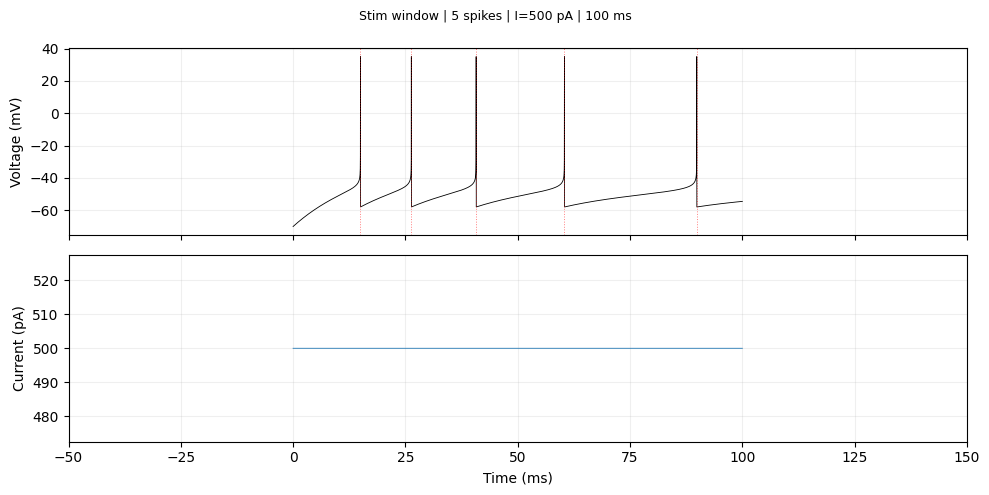

In [4]:
from ADoptEX.loss import (
    extract_experimental_features,
    GuarinoLossConfig,
    make_guarino_loss_fn,
)

training_config = TrainingConfig(
    optimizer="adam",
    learning_rate=0.01,
    n_epochs=1,
    surrogate_type="superspike",
    surrogate_slope=10.0,
    trainable_params=["C_m", "g_L", "E_L", "v_T", "v_reset"],
)

data = TraceData(
    T,
    sim_init.voltage,
    np.full(len(T), initial_params["I"]),
    dt_ms,
    sim_init.spike_times,
    0,
    len(T),
    initial_params["I"])

trace_stim_window_plot(data)

cell, data_stimuli, t_max, trainable_params = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=np.full(len(T), initial_params["I"]), v_init=sim_init.voltage[0],
    dt_ms=dt_ms,
    config=training_config,
)

target_voltage = jnp.array(sim_init.voltage)
stim_end_index = t_max_ms  # already 0-based in cropped trace

loss_name = "Soft-DTW"
loss_fn = make_soft_dtw_loss_fn(
    cell=cell,
    data_stimuli=data_stimuli,
    t_max=t_max,
    dt_ms=dt_ms,
    exp_voltage=target_voltage,
    stim_end_index=len(sim_init.voltage),
    window_size=50,
    stride=30,
    gamma=0.5,
    lambda_temp=10.0,
    spike_peak_mv=SPIKE_PEAK_MV,
)


# Build param name -> index mapping
param_index = {}
for i, p in enumerate(trainable_params):
    for k in p:
        param_index[k.replace("AdEx_", "")] = i

PARAM_NAMES = list(param_index.keys())
N_PARAMS = len(PARAM_NAMES)

loss_init = loss_fn(trainable_params)
print(f"Initial loss: {float(loss_init):.4f}")
print(f"Trainable parameters ({N_PARAMS}): {PARAM_NAMES}")
print(f"Initial parameters: {initial_params}")


## 3. Sweep All Parameter Pairs

For each of the C(7,2) = 21 pairs, build a grid over their PARAM_BOUNDS and
evaluate the loss. Non-swept parameters stay at their default values.

In [5]:
GRID_SIZE = 20  # 20x20 per pair; 21 pairs * 400 = 8400 simulations

pairs = list(combinations(range(N_PARAMS), 2))
print(f"{len(pairs)} parameter pairs, {GRID_SIZE}x{GRID_SIZE} grid each")
print(f"Total simulations: {len(pairs) * GRID_SIZE**2}")

28 parameter pairs, 10x10 grid each
Total simulations: 2800


In [6]:
# Storage for all grids
grids = {}  # (i, j) -> {"X": ..., "Y": ..., "Z": ...}

t_start = time.time()

for pair_idx, (pi, pj) in enumerate(pairs):
    px, py = PARAM_NAMES[pi], PARAM_NAMES[pj]
    bx, by = PARAM_BOUNDS[px], PARAM_BOUNDS[py]

    x_vals = np.linspace(bx.min, bx.max, GRID_SIZE)
    y_vals = np.linspace(by.min, by.max, GRID_SIZE)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.full((GRID_SIZE, GRID_SIZE), np.nan)

    ix, iy = param_index[px], param_index[py]

    pxrc = f"AdEx_{px}" if px != "capacitance" else px
    pyrc = f"AdEx_{py}" if py != "capacitance" else py
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            params_rc = copy.deepcopy(trainable_params)
            params_rc[ix] = {pxrc: jnp.array([X[r, c]])}
            params_rc[iy] = {pyrc: jnp.array([Y[r, c]])}
            try:
                Z[r, c] = float(loss_fn(params_rc))
            except Exception:
                Z[r, c] = np.nan

    grids[(pi, pj)] = {"X": X, "Y": Y, "Z": Z}

    elapsed = time.time() - t_start
    eta = elapsed / (pair_idx + 1) * (len(pairs) - pair_idx - 1)
    print(
        f"  [{pair_idx+1:2d}/{len(pairs)}] {px:>8s} vs {py:<8s}  "
        f"loss=[{np.nanmin(Z):.1f}, {np.nanmax(Z):.1f}]  "
        f"elapsed={elapsed:.0f}s  ETA={eta:.0f}s"
    )

print(f"\nTotal time: {time.time() - t_start:.0f}s")

  [ 1/28] capacitance vs g_L       loss=[4.7, 28.2]  elapsed=23s  ETA=616s
  [ 2/28] capacitance vs E_L       loss=[8.4, 42.6]  elapsed=46s  ETA=594s
  [ 3/28] capacitance vs v_T       loss=[6.4, 39.1]  elapsed=72s  ETA=599s
  [ 4/28] capacitance vs v_reset   loss=[2.1, 73.1]  elapsed=97s  ETA=579s
  [ 5/28] capacitance vs tau_w     loss=[7.7, 35.0]  elapsed=126s  ETA=579s
  [ 6/28] capacitance vs a         loss=[5.2, 26.0]  elapsed=156s  ETA=571s
  [ 7/28] capacitance vs b         loss=[6.1, 147.4]  elapsed=186s  ETA=559s
  [ 8/28]      g_L vs E_L       loss=[2.2, 52.4]  elapsed=217s  ETA=543s
  [ 9/28]      g_L vs v_T       loss=[2.6, 28.0]  elapsed=248s  ETA=523s
  [10/28]      g_L vs v_reset   loss=[4.3, 34.5]  elapsed=278s  ETA=500s
  [11/28]      g_L vs tau_w     loss=[1.1, 22.0]  elapsed=312s  ETA=482s
  [12/28]      g_L vs a         loss=[0.7, 20.9]  elapsed=345s  ETA=459s
  [13/28]      g_L vs b         loss=[1.1, 24.1]  elapsed=376s  ETA=433s
  [14/28]      E_L vs v_T       l

## 4. Triangle Grid — All Pairs (2D Contour)

Lower-triangle matrix: row = second parameter, column = first parameter.
Each cell shows a filled contour of the loss landscape for that pair.

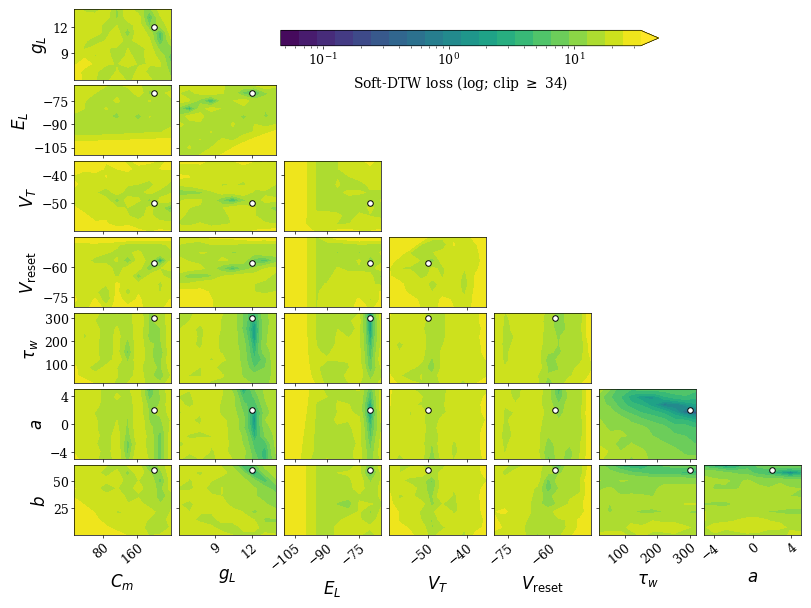

Saved to soft-dtw_loss_landscape_grid.pdf
Loss range across all pairs: [0.046, 795]
Colorbar clip at 95th percentile: 33.9


In [9]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation, MaxNLocator

PARAM_LABELS = {
    "capacitance": r"$C_m$",
    "g_L": r"$g_L$",
    "E_L": r"$E_L$",
    "v_T": r"$V_T$",
    "delta_T": r"$\Delta_T$",
    "v_reset": r"$V_\mathrm{reset}$",
    "tau_w": r"$\tau_w$",
    "a": r"$a$",
    "b": r"$b$",
}

# Units per loss function (missing entries render without a unit bracket)
LOSS_UNITS = {
    "MSE": r"mV$^2$",
}

def _map_name_to_initial(s):
    return "C_m" if s == "capacitance" else s

all_Z = np.concatenate([g["Z"].ravel() for g in grids.values()])
positive = all_Z[np.isfinite(all_Z) & (all_Z > 0)]
vmin = float(np.min(positive)) if positive.size else 1e-6
vmax_clip = float(np.nanpercentile(all_Z, 95))
vmax_clip = max(vmax_clip, vmin * 10)
vmax_true = float(np.nanmax(all_Z))
norm = LogNorm(vmin=vmin, vmax=vmax_clip)
levels = np.geomspace(vmin, vmax_clip, 21)

# Rendered at thesis print size: ~9x7 inches fits full-page landscape on A4
# (use \begin{sidewaysfigure}\includegraphics{...}\end{sidewaysfigure} in LaTeX).
# Fonts stay legible because LaTeX no longer rescales the figure.
with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.6,
}):
    fig, axes = plt.subplots(
        N_PARAMS, N_PARAMS, figsize=(9.0, 7.0), squeeze=False,
    )

    # Diagonal cells stay hidden — redundant with outer row/column labels.
    for ax_row in axes:
        for ax in ax_row:
            ax.set_visible(False)

    mappable = None
    for (pi, pj), g in grids.items():
        ax = axes[pj, pi]
        ax.set_visible(True)

        Z_plot = np.clip(g["Z"], vmin, vmax_clip)
        cs = ax.contourf(
            g["X"], g["Y"], Z_plot,
            levels=levels, cmap="viridis", norm=norm, extend="max",
        )
        if mappable is None:
            mappable = cs

        ax.plot(
            initial_params[_map_name_to_initial(PARAM_NAMES[pi])],
            initial_params[_map_name_to_initial(PARAM_NAMES[pj])],
            marker="o", markersize=4,
            markerfacecolor="white", markeredgecolor="black", markeredgewidth=0.7,
            linestyle="none",
        )

        if pj == N_PARAMS - 1:
            ax.set_xlabel(PARAM_LABELS[PARAM_NAMES[pi]], fontsize=12, labelpad=4)
            for lbl in ax.get_xticklabels():
                lbl.set_rotation(40)
                lbl.set_ha("right")
                lbl.set_rotation_mode("anchor")
        else:
            ax.set_xticklabels([])
        if pi == 0:
            ax.set_ylabel(PARAM_LABELS[PARAM_NAMES[pj]], fontsize=12, labelpad=3)
        else:
            ax.set_yticklabels([])

        ax.xaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.yaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.tick_params(direction="out", length=2.2, width=0.5, pad=1.5)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    fig.subplots_adjust(
        left=0.06, right=0.985, bottom=0.11, top=0.97,
        wspace=0.08, hspace=0.08,
    )

    pos_row = axes[1, 0].get_position()
    cbar_width = 0.42
    cbar_ax = fig.add_axes([
        0.5 - cbar_width / 2,
        pos_row.y0 + pos_row.height * 0.48,
        cbar_width,
        pos_row.height * 0.22,
    ])
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal", extend="max")

    lo = int(np.floor(np.log10(vmin)))
    hi = int(np.ceil(np.log10(vmax_clip)))
    cbar.ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=min(hi - lo + 1, 8)))
    cbar.ax.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10), numticks=50)
    )
    cbar.ax.xaxis.set_major_formatter(LogFormatterSciNotation(base=10))
    cbar.ax.tick_params(
        which="major", labelsize=9, direction="out", length=2.5, width=0.5, pad=1.5
    )
    cbar.ax.tick_params(which="minor", direction="out", length=1.6, width=0.4)
    cbar.outline.set_linewidth(0.5)

    unit_str = LOSS_UNITS.get(loss_name)
    unit_bracket = f"  [{unit_str}]" if unit_str else ""
    cbar.set_label(
        rf"{loss_name} loss{unit_bracket} (log; clip $\geq$ {vmax_clip:.2g})",
        fontsize=10, labelpad=4,
    )

    plt.savefig(
        f"{loss_name.lower()}_loss_landscape_grid.pdf", dpi=300, bbox_inches="tight"
    )
    plt.show()
    print(f"Saved to {loss_name.lower()}_loss_landscape_grid.pdf")
    print(f"Loss range across all pairs: [{float(np.nanmin(all_Z)):.3g}, {vmax_true:.3g}]")
    print(f"Colorbar clip at 95th percentile: {vmax_clip:.3g}")


## 5. Gradient Landscape

Same grid as section 3, but at each point evaluates `jax.grad(loss_fn)` and
records the partial derivatives w.r.t. the two swept parameters. The triangle
grid below shows the gradient magnitude (log scale) with normalized quiver
arrows for direction.

In [ ]:
grad_fn = jax.grad(loss_fn)

grad_grids = {}
t_start = time.time()
for pair_idx, (pi, pj) in enumerate(pairs):
    px, py = PARAM_NAMES[pi], PARAM_NAMES[pj]
    pxrc = f"AdEx_{px}" if px != "capacitance" else px
    pyrc = f"AdEx_{py}" if py != "capacitance" else py
    g = grids[(pi, pj)]
    X, Y = g["X"], g["Y"]
    ix, iy = param_index[px], param_index[py]
    GX = np.full((GRID_SIZE, GRID_SIZE), np.nan)
    GY = np.full((GRID_SIZE, GRID_SIZE), np.nan)
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            params_rc = copy.deepcopy(trainable_params)
            params_rc[ix] = {pxrc: jnp.array([X[r, c]])}
            params_rc[iy] = {pyrc: jnp.array([Y[r, c]])}
            try:
                gd = grad_fn(params_rc)
                GX[r, c] = float(gd[ix][pxrc][0])
                GY[r, c] = float(gd[iy][pyrc][0])
            except Exception:
                pass
    MAG = np.sqrt(GX ** 2 + GY ** 2)
    # Bound-normalised gradient: scale each component by its bound width
    # so the quiver direction reflects landscape geometry rather than
    # raw partial-derivative units (mV vs nS, etc.). Same dimensionless
    # parametrisation as the recovery-radius benchmark perturbation.
    SCALE_X = PARAM_BOUNDS[px].max - PARAM_BOUNDS[px].min
    SCALE_Y = PARAM_BOUNDS[py].max - PARAM_BOUNDS[py].min
    GX_n = GX * SCALE_X
    GY_n = GY * SCALE_Y
    MAG_n = np.sqrt(GX_n ** 2 + GY_n ** 2)
    grad_grids[(pi, pj)] = {
        "X": X, "Y": Y,
        "GX": GX, "GY": GY, "MAG": MAG,
        "GX_n": GX_n, "GY_n": GY_n, "MAG_n": MAG_n,
    }
    elapsed = time.time() - t_start
    eta = elapsed / (pair_idx + 1) * (len(pairs) - pair_idx - 1)
    print(
        f"  [{pair_idx+1:2d}/{len(pairs)}] {px:>8s} vs {py:<8s}  "
        f"|grad|=[{np.nanmin(MAG):.2g}, {np.nanmax(MAG):.2g}]  "
        f"elapsed={elapsed:.0f}s  ETA={eta:.0f}s"
    )
print(f"\nTotal time: {time.time() - t_start:.0f}s")

In [ ]:
all_M = np.concatenate([g["MAG_n"].ravel() for g in grad_grids.values()])
positive_M = all_M[np.isfinite(all_M) & (all_M > 0)]
gmin = float(np.min(positive_M)) if positive_M.size else 1e-12
gmax_clip = float(np.nanpercentile(all_M, 95))
gmax_clip = max(gmax_clip, gmin * 10)
gmax_true = float(np.nanmax(all_M))
gnorm = LogNorm(vmin=gmin, vmax=gmax_clip)
glevels = np.geomspace(gmin, gmax_clip, 21)

with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.6,
}):
    fig, axes = plt.subplots(N_PARAMS, N_PARAMS, figsize=(9.0, 7.0), squeeze=False)
    for ax_row in axes:
        for ax in ax_row:
            ax.set_visible(False)

    mappable = None
    for (pi, pj), g in grad_grids.items():
        ax = axes[pj, pi]
        ax.set_visible(True)

        M = np.clip(g["MAG_n"], gmin, gmax_clip)
        cs = ax.contourf(
            g["X"], g["Y"], M,
            levels=glevels, cmap="magma", norm=gnorm, extend="max",
        )
        if mappable is None:
            mappable = cs

        step = max(1, GRID_SIZE // 3)
        Xs = g["X"][::step, ::step]
        Ys = g["Y"][::step, ::step]
        GXs = g["GX_n"][::step, ::step]
        GYs = g["GY_n"][::step, ::step]
        Ms = np.sqrt(GXs ** 2 + GYs ** 2)
        denom = np.where(Ms > 0, Ms, 1.0)
        U = GXs / denom
        V = GYs / denom
        ax.quiver(
            Xs, Ys, U, V,
            color="white", edgecolor="black", linewidth=0.25,
            alpha=0.95, pivot="middle",
            angles="xy", scale_units="width",
            scale=14, width=0.005,
            headwidth=4, headlength=5, headaxislength=4.5,
            minshaft=2, minlength=0.1,
        )

        ax.plot(
            initial_params[_map_name_to_initial(PARAM_NAMES[pi])],
            initial_params[_map_name_to_initial(PARAM_NAMES[pj])],
            marker="o", markersize=4,
            markerfacecolor="white", markeredgecolor="black", markeredgewidth=0.7,
            linestyle="none",
        )

        if pj == N_PARAMS - 1:
            ax.set_xlabel(PARAM_LABELS[PARAM_NAMES[pi]], fontsize=12, labelpad=4)
            for lbl in ax.get_xticklabels():
                lbl.set_rotation(40)
                lbl.set_ha("right")
                lbl.set_rotation_mode("anchor")
        else:
            ax.set_xticklabels([])
        if pi == 0:
            ax.set_ylabel(PARAM_LABELS[PARAM_NAMES[pj]], fontsize=12, labelpad=3)
        else:
            ax.set_yticklabels([])

        ax.xaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.yaxis.set_major_locator(MaxNLocator(3, prune="both"))
        ax.tick_params(direction="out", length=2.2, width=0.5, pad=1.5)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    fig.subplots_adjust(
        left=0.06, right=0.985, bottom=0.11, top=0.97,
        wspace=0.08, hspace=0.08,
    )

    pos_row = axes[1, 0].get_position()
    cbar_width = 0.42
    cbar_ax = fig.add_axes([
        0.5 - cbar_width / 2,
        pos_row.y0 + pos_row.height * 0.48,
        cbar_width,
        pos_row.height * 0.22,
    ])
    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation="horizontal", extend="max")

    lo = int(np.floor(np.log10(gmin)))
    hi = int(np.ceil(np.log10(gmax_clip)))
    cbar.ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=min(hi - lo + 1, 8)))
    cbar.ax.xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10), numticks=50)
    )
    cbar.ax.xaxis.set_major_formatter(LogFormatterSciNotation(base=10))
    cbar.ax.tick_params(
        which="major", labelsize=9, direction="out", length=2.5, width=0.5, pad=1.5
    )
    cbar.ax.tick_params(which="minor", direction="out", length=1.6, width=0.4)
    cbar.outline.set_linewidth(0.5)
    cbar.set_label(
        rf"$\|\nabla\,${loss_name}$\,\odot\,\Delta\theta\|_2$ (log; clip $\geq$ {gmax_clip:.2g})",
        fontsize=10, labelpad=4,
    )

    plt.savefig(
        f"{loss_name.lower()}_grad_landscape_grid.pdf", dpi=300, bbox_inches="tight"
    )
    plt.show()
    print(f"Saved to {loss_name.lower()}_grad_landscape_grid.pdf")
    print(f"Gradient magnitude range: [{float(np.nanmin(all_M)):.3g}, {gmax_true:.3g}]")
    print(f"Colorbar clip at 95th percentile: {gmax_clip:.3g}")

## 5. Individual 3D Surface Plots

Ackley-style 3D surface with contour projection for each parameter pair.

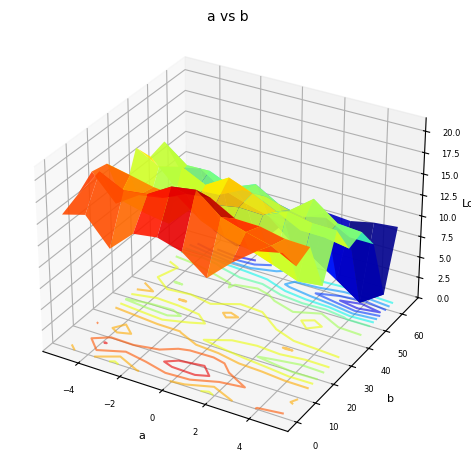

In [8]:
ax = plt.subplot(projection="3d")

surf = ax.plot_surface(
    X,
    Y,
    Z_plot,
    cmap=cm.jet,
    edgecolor="none",
    alpha=0.9,
    rstride=1,
    cstride=1,
)

# Contour projection on the floor
z_floor = ax.get_zlim()[0]
ax.contour(
    X,
    Y,
    Z_plot,
    levels=10,
    zdir="z",
    offset=z_floor,
    cmap=cm.jet,
    alpha=0.6,
)

ax.set_xlabel(px, fontsize=8, labelpad=2)
ax.set_ylabel(py, fontsize=8, labelpad=2)
ax.set_zlabel("Loss", fontsize=8, labelpad=2)
ax.set_title(f"{px} vs {py}", fontsize=10, pad=2)
ax.tick_params(labelsize=6)
ax.view_init(elev=30, azim=-60)

plt.tight_layout()
# plt.savefig(
#     f"{loss_name.lower()}_loss_landscape_3d_focus.pdf", dpi=150, bbox_inches="tight"
# )
plt.show()
# print(f"Saved to {loss_name.lower()}_loss_landscape_3d_focus.png")